# Keypoint Classification with 1D CNN

## 1. Project Overview

In this project we build an **AI model** that recognises **hand gestures** from
**21 hand keypoints** (2D `(x, y)` coordinates) extracted using
Google Mediapipe.

Each sample in the dataset is:

- One frame of a **single hand gesture**.
- Represented by **42 numeric features**:  
  $\begin{bmatrix} x_1 & y_1 & x_2 & y_2 & \dots & x_{21} & y_{21} \end{bmatrix}$
- Labelled with an **integer gesture class** (0–N).

## 2. 1D Convolutional Neural Network (1D CNN)

We use a **1D CNN** to process the sequence of keypoints. While keypoints are spatial, treating them as a 1D sequence allows the CNN to learn local patterns and relationships between adjacent keypoints (e.g., finger segments).


In [6]:
import csv
from pathlib import Path

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers


In [7]:
RANDOM_SEED = 42
NUM_CLASSES = 10
DATASET_PATH = Path('../data/keypoint_10gestures_60k.csv')
MODEL_SAVE_PATH = Path('../models/keypoint/keypoint_classifier_1dcnn.keras')
TFLITE_SAVE_PATH = Path('../models/keypoint/keypoint_classifier_1dcnn.tflite')

In [8]:
X_dataset = np.loadtxt(DATASET_PATH, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))
y_dataset = np.loadtxt(DATASET_PATH, delimiter=',', dtype='int32', usecols=(0,))

X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, y_dataset,
    train_size=0.75,
    random_state=RANDOM_SEED,
    stratify=y_dataset  # 关键：按类别分层，避免数据偏移
)

In [9]:
# ===========================================
# 2. 关键点归一化（强烈推荐）
# ===========================================
def normalize_keypoints(X):
    X = X.copy().astype(np.float32)

    # wrist 位置（第 0 点的 x, y）
    wrist_x = X[:, 0]
    wrist_y = X[:, 1]

    # 平移：所有 keypoint 减去 wrist 坐标
    X[:, 0:42:2] -= wrist_x[:, None]
    X[:, 1:42:2] -= wrist_y[:, None]

    # 缩放：按每个样本独立最大值进行归一化
    scale = np.max(np.abs(X), axis=1, keepdims=True)
    scale[scale == 0] = 1e-6
    X = X / scale

    return X
X_train = normalize_keypoints(X_train)
X_test = normalize_keypoints(X_test)

In [10]:
# ===========================================
# 3. 数据增强（关键点 jitter）
# ===========================================
def augment(X):
    noise = np.random.normal(0, 0.01, X.shape).astype(np.float32)
    return X + noise

# # 数据增强 + reshape
# X_train_aug = augment(X_train)

# 数据增强 + reshape
X_train_aug = augment(X_train).reshape(-1, 21, 2)
X_test = X_test.reshape(-1, 21, 2)

In [11]:
# ===========================================
# 4. Optimizer：AdamW + Cosine LR
# ===========================================
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=3e-4,
    first_decay_steps=2000,
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

In [12]:
# ===========================================
# 5. 模型结构（验证稳定、效果最佳 MLP）0.66
# ===========================================
model0 = tf.keras.Sequential([
    layers.Input((42,)),

    layers.Dense(256, activation='gelu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='gelu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='gelu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(64, activation='gelu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 5. 构建 1D-CNN 模型
# ==============================
model = tf.keras.Sequential([
    layers.Input(shape=(21, 2)),

    layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv1D(256, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# ===========================================
# 6. EarlyStopping（避免震荡）
# ===========================================
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

In [14]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(str(MODEL_SAVE_PATH), save_best_only=True)

In [15]:

history = model.fit(
    X_train_aug, y_train,
    validation_data=(X_test, y_test),
    epochs=300,
    batch_size=128,
    callbacks=[checkpoint_cb,early_stop_cb],  # ✅ 在这里传入
    verbose=1
)

Epoch 1/300
355/355 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5308 - loss: 1.4301 - val_accuracy: 0.1655 - val_loss: 3.6711
Epoch 2/300
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7853 - loss: 0.6542 - val_accuracy: 0.8805 - val_loss: 0.3717
Epoch 3/300
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8453 - loss: 0.4846 - val_accuracy: 0.9121 - val_loss: 0.2871
Epoch 4/300
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8736 - loss: 0.4043 - val_accuracy: 0.9231 - val_loss: 0.2519
Epoch 5/300
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8849 - loss: 0.3670 - val_accuracy: 0.9276 - val_loss: 0.2417
Epoch 6/300
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8824 - loss: 0.3709 - val_accuracy: 0.9198 - val_loss: 0.2651
Epoch 7/300
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8942 - loss: 0.3409 - val_accuracy: 0.9353 - val_loss: 0.2105
Epoch 8/300
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9119 - loss: 0.2857 - 

In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_quantized_model = converter.convert()
TFLITE_SAVE_PATH.write_bytes(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\brian\AppData\Local\Temp\tmpddp_7430\assets


INFO:tensorflow:Assets written to: C:\Users\brian\AppData\Local\Temp\tmpddp_7430\assets


Saved artifact at 'C:\Users\brian\AppData\Local\Temp\tmpddp_7430'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 21, 2), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2292354030416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354033296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354033680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354034640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354034448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354033872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354034256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354033488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354032912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354035792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2292354

233616

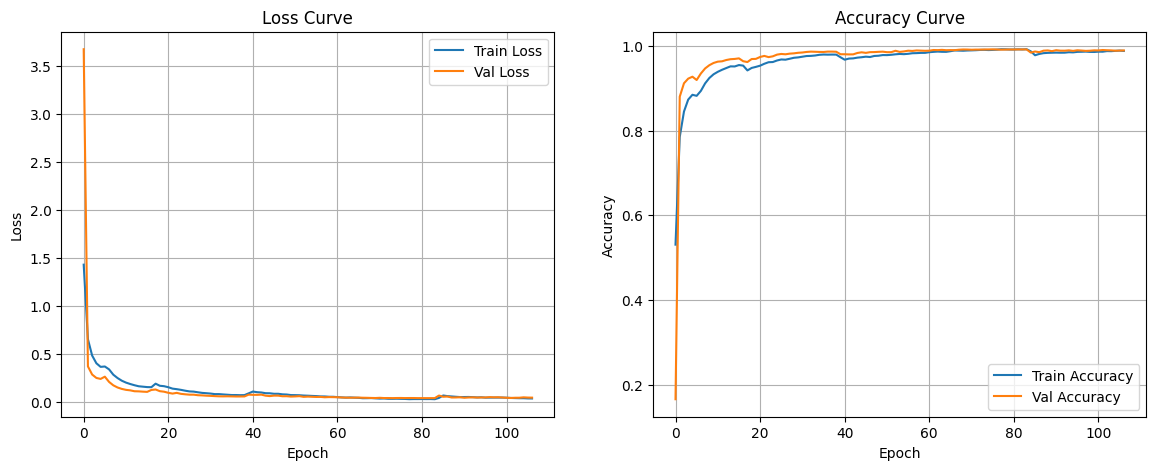


📊 Detailed Model Performance Comparison
Metric               Train        Test        
-------------------------------------------------------
Loss                 0.0383       0.0418
Accuracy             0.9987       0.9921
Macro Precision      0.9987       0.9921
Macro Recall         0.9988       0.9921
Macro F1             0.9988       0.9921
-------------------------------------------------------
⚡ Avg Inference Time: 0.0806 ms/sample

✅  Model seems well-balanced (Good fit).




<Figure size 800x800 with 0 Axes>

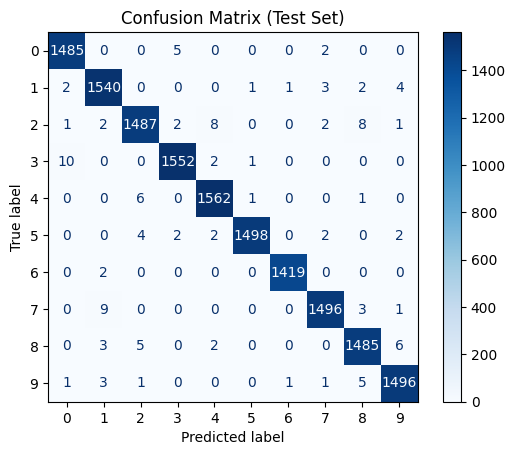


📌 Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1492
           1       0.99      0.99      0.99      1553
           2       0.99      0.98      0.99      1511
           3       0.99      0.99      0.99      1565
           4       0.99      0.99      0.99      1570
           5       1.00      0.99      1.00      1510
           6       1.00      1.00      1.00      1421
           7       0.99      0.99      0.99      1509
           8       0.99      0.99      0.99      1501
           9       0.99      0.99      0.99      1508

    accuracy                           0.99     15140
   macro avg       0.99      0.99      0.99     15140
weighted avg       0.99      0.99      0.99     15140



In [18]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, precision_score, recall_score

# =============================
# 1. 绘制 Loss 和 Accuracy 曲线
# =============================

plt.figure(figsize=(14, 5))

# ---- Loss ----
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ---- Accuracy ----
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# =============================
# 2. 打印 Train & Test Set 评估指标对比
# =============================

# Reshape X_train for prediction if necessary (assuming 1D CNN expects 3D input)
# Check if X_train needs reshaping based on model input shape
if len(X_train.shape) == 2:
     X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1] // 2, 2)
else:
     X_train_reshaped = X_train

# Predictions
y_train_pred_probs = model.predict(X_train_reshaped, verbose=0)
y_train_pred = np.argmax(y_train_pred_probs, axis=1)

y_test_pred_probs = model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# Metrics Calculation
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

train_prec = precision_score(y_train, y_train_pred, average='macro')
test_prec = precision_score(y_test, y_test_pred, average='macro')

train_rec = recall_score(y_train, y_train_pred, average='macro')
test_rec = recall_score(y_test, y_test_pred, average='macro')

# Loss
train_loss = history.history['loss'][-1]
test_loss, _ = model.evaluate(X_test, y_test, verbose=0)

# Inference Time Measurement
start_time = time.time()
model.predict(X_test, verbose=0)
end_time = time.time()
inference_time_ms = ((end_time - start_time) / len(X_test)) * 1000

# Print Comparison Table
print("\n" + "="*55)
print("📊 Detailed Model Performance Comparison")
print("="*55)
print(f"{'Metric':<20} {'Train':<12} {'Test':<12}")
print("-" * 55)
print(f"{'Loss':<20} {train_loss:.4f}       {test_loss:.4f}")
print(f"{'Accuracy':<20} {train_acc:.4f}       {test_acc:.4f}")
print(f"{'Macro Precision':<20} {train_prec:.4f}       {test_prec:.4f}")
print(f"{'Macro Recall':<20} {train_rec:.4f}       {test_rec:.4f}")
print(f"{'Macro F1':<20} {train_f1:.4f}       {test_f1:.4f}")
print("-" * 55)
print(f"⚡ Avg Inference Time: {inference_time_ms:.4f} ms/sample")
print("="*55 + "\n")

# Interpretation
if train_acc > test_acc + 0.05:
    print("⚠️  Potential OVERFITTING: Train accuracy is significantly higher than Test accuracy.")
    print("   Consider increasing Dropout, adding L2 regularization, or using more data augmentation.")
elif train_acc < 0.80:
    print("⚠️  Potential UNDERFITTING: Train accuracy is relatively low.")
    print("   Consider increasing model complexity (more layers/units) or training for longer.")
else:
    print("✅  Model seems well-balanced (Good fit).")
print("\n")


# =============================
# 3. 混淆矩阵 + 可视化 (Test Set)
# =============================

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (Test Set)")
plt.show()

# =============================
# 4. Test Set 详细分类报告
# =============================
print("\n📌 Test Set Classification Report:")
print(classification_report(y_test, y_test_pred))
